# OULAD Model Training Pipeline

## Overview
This notebook trains a Random Forest model to predict student performance. 
It includes Deep Exploratory Data Analysis (EDA) and professional evaluation metrics (ROC Curve, Feature Importance).

**Objective:** Predict pass/fail based on pre-exam academic performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# Plot Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Configuration
DATA_DIR = '.'
MODEL_DIR = '../Saved_Models'
RANDOM_STATE = 42

if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

# Load Data
print("Loading Datasets...")
try:
    df_studentInfo = pd.read_csv(os.path.join(DATA_DIR, 'studentInfo.csv'))
    df_studentAssessment = pd.read_csv(os.path.join(DATA_DIR, 'studentAssessment.csv'))
    df_assessments = pd.read_csv(os.path.join(DATA_DIR, 'assessments.csv'))
    df_studentVle = pd.read_csv(os.path.join(DATA_DIR, 'studentVle.csv'))
    print("Datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading data: {e}")

Loading Datasets...
Datasets loaded successfully.


## 1. Feature Engineering
Aggregating student data while strictly excluding exams.

In [3]:
print("Processing Assessments...")
# Merge assessments
df_sa_merged = df_studentAssessment.merge(df_assessments, on='id_assessment', how='left')

# EXCLUDE EXAMS
df_sa_merged = df_sa_merged[df_sa_merged['assessment_type'] != 'Exam']

# Calculate Weighted Score
df_sa_merged['weighted_score'] = df_sa_merged['score'] * (df_sa_merged['weight'] / 100)

# Aggregate per student
agg_assess = df_sa_merged.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    Weighted_grade=('weighted_score', 'sum'),
    Score_tma=('score', lambda x: x[df_sa_merged.loc[x.index, 'assessment_type'] == 'TMA'].mean()),
    Score_cma=('score', lambda x: x[df_sa_merged.loc[x.index, 'assessment_type'] == 'CMA'].mean()),
    Assessments_Taken=('id_assessment', 'count')
).reset_index()

# Calculate Submission Rate
total_assessments = df_assessments[df_assessments['assessment_type'] != 'Exam'].groupby(['code_module', 'code_presentation']).size().reset_index(name='Total_Count')
agg_assess = agg_assess.merge(total_assessments, on=['code_module', 'code_presentation'], how='left')
agg_assess['Pass_rate'] = (agg_assess['Assessments_Taken'] / agg_assess['Total_Count']) * 100

print("Processing VLE interactions...")
agg_vle = df_studentVle.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    Sum_click=('sum_click', 'sum'),
    Days_Active=('date', 'max')
).reset_index()

print("Merging Datasets...")
final_df = df_studentInfo.merge(agg_assess, on=['id_student', 'code_module', 'code_presentation'], how='left')
final_df = final_df.merge(agg_vle, on=['id_student', 'code_module', 'code_presentation'], how='left')

# Create Target
final_df['target'] = final_df['final_result'].apply(lambda x: 1 if x in ['Pass', 'Distinction'] else 0)

feature_cols = ['Weighted_grade', 'Pass_rate', 'Score_tma', 'Score_cma', 'Sum_click', 'Days_Active', 'num_of_prev_attempts']
numeric_cols = feature_cols

Processing Assessments...
Processing VLE interactions...
Merging Datasets...


## 2. Advanced EDA & Missing Value Analysis
Visualizing data gaps and distributions to justify our cleaning strategy.


 MISSING VALUE ANALYSIS:
                      Count    Percent
Score_cma             17493  53.671034
Score_tma              7805  23.946860
Weighted_grade         6754  20.722241
Pass_rate              6754  20.722241
Sum_click              3365  10.324303
Days_Active            3365  10.324303
num_of_prev_attempts      0   0.000000


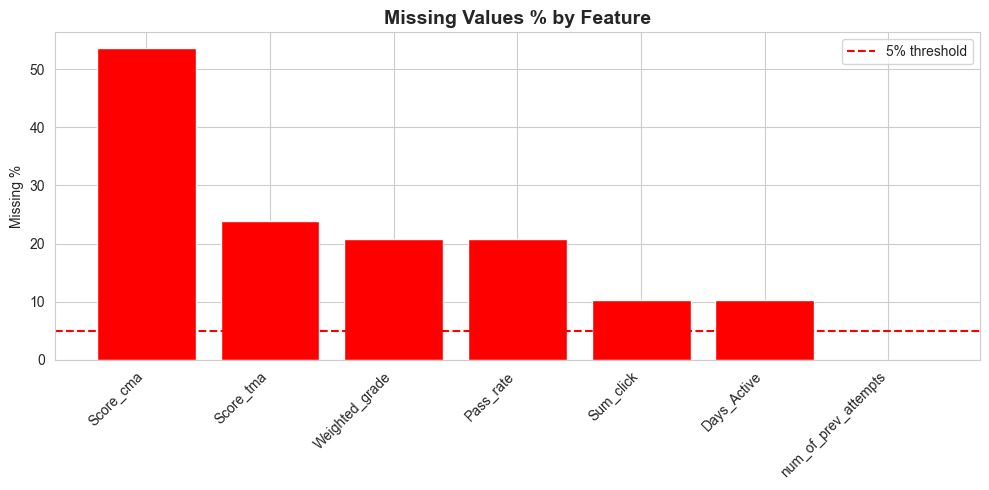

In [4]:
# 2. Missing Value Analysis
print('\n MISSING VALUE ANALYSIS:')
missing = final_df[feature_cols].isnull().sum()
missing_pct = (missing / len(final_df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct}).sort_values('Percent', ascending=False)
print(missing_df)

# Visualize Missing Values
plt.figure(figsize=(10, 5))
colors = ['red' if p > 5 else 'orange' if p > 0 else 'green' for p in missing_df['Percent']]
plt.bar(missing_df.index, missing_df['Percent'], color=colors)
plt.title('Missing Values % by Feature', fontsize=14, fontweight='bold')
plt.ylabel('Missing %')
plt.axhline(y=5, color='r', linestyle='--', label='5% threshold')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

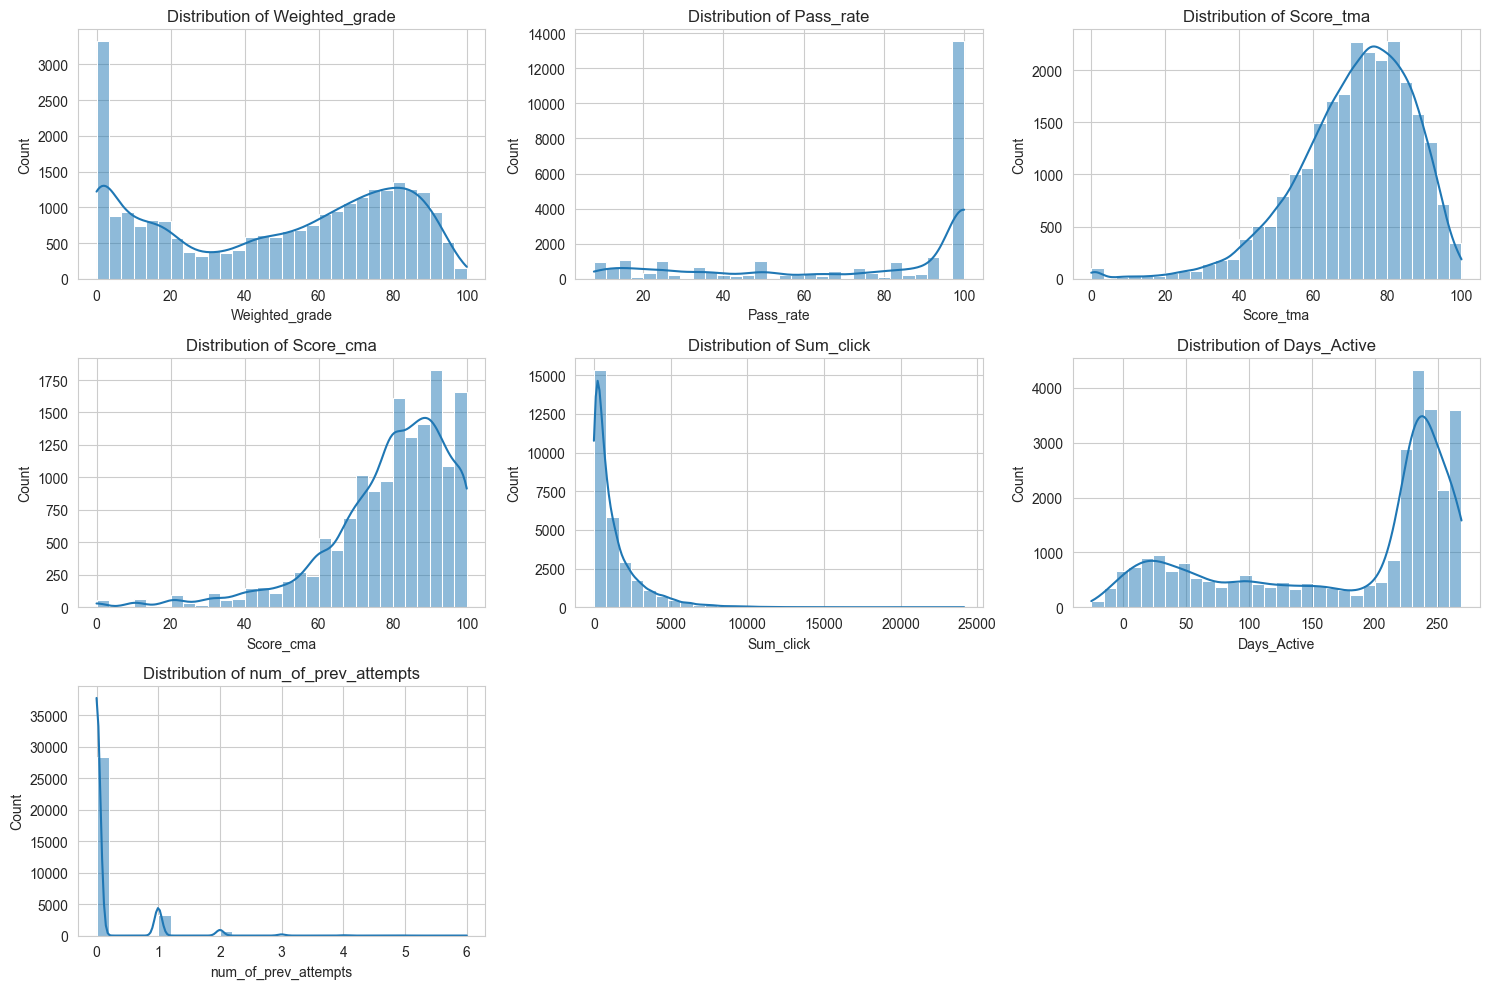

In [5]:
# Distribution of Features
plt.figure(figsize=(15, 10))
num_features = len(feature_cols)
rows = (num_features + 2) // 3
for i, col in enumerate(feature_cols, 1):
    plt.subplot(rows, 3, i)
    sns.histplot(final_df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

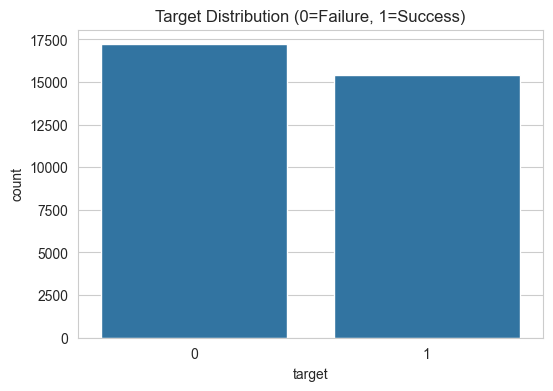

In [6]:
# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=final_df)
plt.title('Target Distribution (0=Failure, 1=Success)')
plt.show()

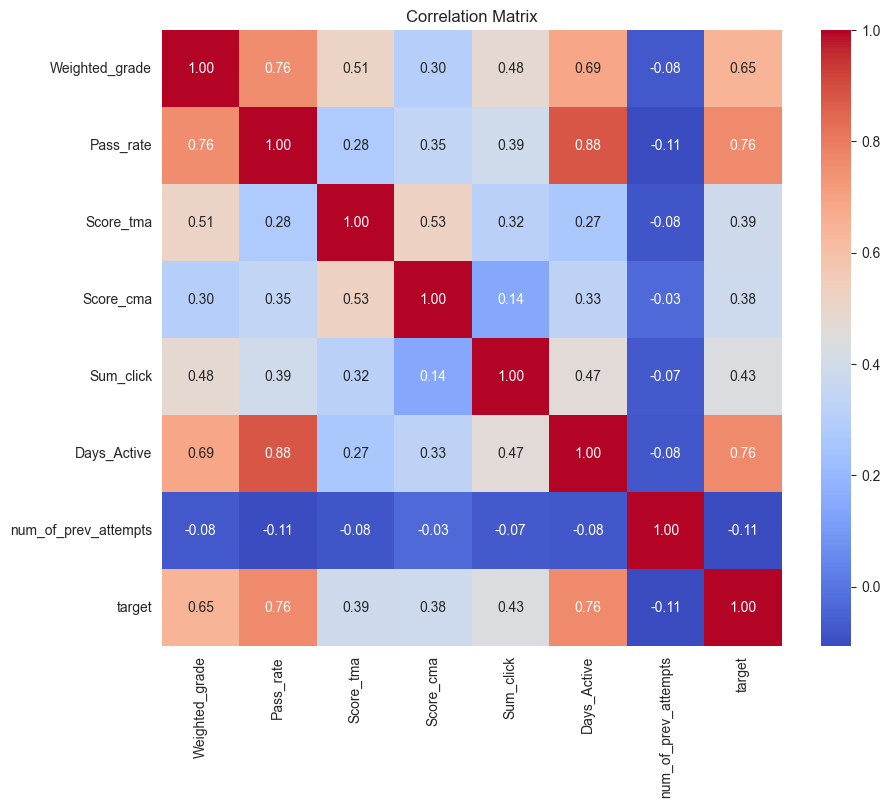

In [7]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
available_cols = [c for c in numeric_cols if c in final_df.columns]
corr_cols = available_cols + ['target']
sns.heatmap(final_df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 3. Smart Data Cleaning
Implementing specific missing value handling strategy.

In [8]:
# 2. Smart Missing Value Handling
print('Missing values BEFORE handling:')
print(final_df.isnull().sum())

# Strategy:
# - Drop rows where Score_cma or Score_tma are missing (insufficient data)
# - Fill Date with -1
cols_with_nan_to_drop = ['Score_cma','Score_tma']
final_df = final_df.dropna(subset=cols_with_nan_to_drop)

# Note: Our column is 'Days_Active', user logic applies here as Date
final_df['Days_Active'] = final_df['Days_Active'].fillna(-1)

final_df['Weighted_grade'] = final_df['Weighted_grade'].fillna(final_df['Weighted_grade'].median())
final_df['Pass_rate'] = final_df['Pass_rate'].fillna(final_df['Pass_rate'].median())

# Fill remaining NaNs (for robust modeling)
final_df = final_df.fillna(0)

print('\nMissing values AFTER handling:')
print(final_df.isnull().sum())
print(f"Final shape for modeling: {final_df.shape}")

Missing values BEFORE handling:
code_module                 0
code_presentation           0
id_student                  0
gender                      0
region                      0
highest_education           0
imd_band                 1111
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
Weighted_grade           6754
Score_tma                7805
Score_cma               17493
Assessments_Taken        6754
Total_Count              6754
Pass_rate                6754
Sum_click                3365
Days_Active              3365
target                      0
dtype: int64

Missing values AFTER handling:
code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_r

## 4. Model Training & Validation

In [9]:
# Prepare Data
X = final_df[feature_cols]
y = final_df['target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_STATE)

# Training
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
print("Training Complete.")

Training Random Forest...
Training Complete.


In [10]:
# Standard Evaluation
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9076376554174067

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.79      0.85       903
           1       0.91      0.96      0.93      1912

    accuracy                           0.91      2815
   macro avg       0.91      0.88      0.89      2815
weighted avg       0.91      0.91      0.91      2815



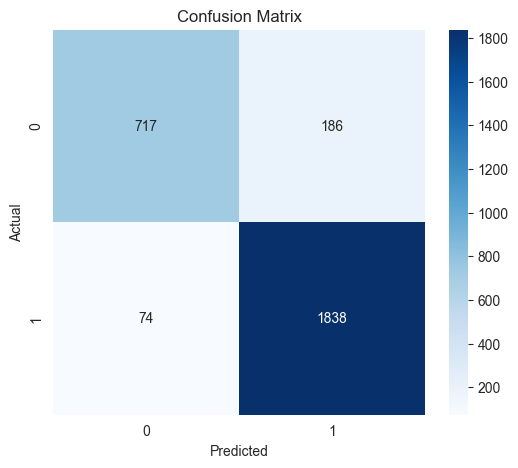

In [11]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

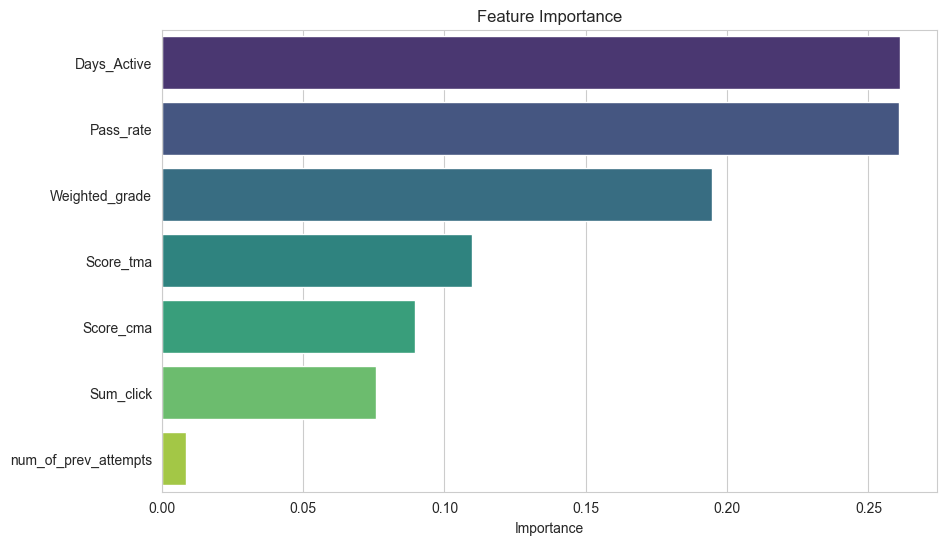

In [12]:
# 2. Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
names = [feature_cols[i] for i in indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=names, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.show()

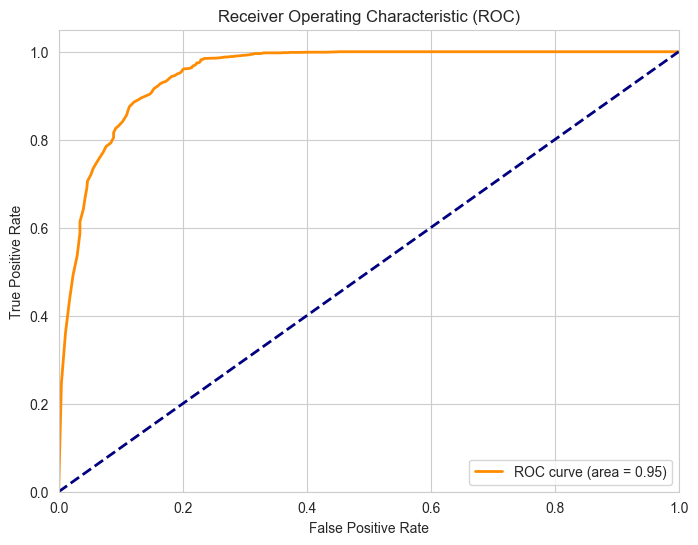

In [13]:
# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [14]:
# Saving
rf_model.feature_names_in_ = feature_cols

if os.path.exists(os.path.join(MODEL_DIR, 'oulad_model_fixed.joblib')):
    os.remove(os.path.join(MODEL_DIR, 'oulad_model_fixed.joblib'))

joblib.dump(rf_model, os.path.join(MODEL_DIR, 'oulad_model_fixed.joblib'))
joblib.dump(scaler, os.path.join(MODEL_DIR, 'oulad_scaler_fixed.joblib'))
print("Model saved successfully.")
print("Features:", feature_cols)

Model saved successfully.
Features: ['Weighted_grade', 'Pass_rate', 'Score_tma', 'Score_cma', 'Sum_click', 'Days_Active', 'num_of_prev_attempts']
